# HRD 2026 Team Optimizer

**Objective:** Pick 8 players (7 starters + 1 backup) from the 251-player pool to **maximize projected 2026 HRs** under a **172 HR salary cap** (each player's 2025 HR total = cost).

**Pipeline:**
1. Ingest player pool parsed from `hrd-available-players-26.pdf`
2. Fetch 2022–2025 batting stats via **pybaseball** (FanGraphs)
3. Build **Marcel-style 2026 HR projections** (weighted 3-yr avg + regression to mean + age curve)
4. Solve **0-1 integer knapsack** with `scipy.optimize.milp`
5. Sensitivity / value-efficiency analysis


In [1]:
import subprocess, sys
for pkg in ['pybaseball','scipy','matplotlib','seaborn']:
    subprocess.run([sys.executable,'-m','pip','install','-q',pkg], check=True)
print('packages ready')


packages ready


In [2]:
import pandas as pd
import numpy as np
import re, warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from difflib import get_close_matches

import pybaseball
pybaseball.cache.enable()
from pybaseball import batting_stats

from scipy.optimize import milp, LinearConstraint, Bounds

pd.set_option('display.max_rows', 60)
pd.set_option('display.float_format', '{:.1f}'.format)
sns.set_theme(style='whitegrid')


In [3]:
# 251 players parsed from hrd-available-players-26.pdf
# Format: (Name, Team, 2025 HR cost)
POOL = [
    ("Cal Raleigh", "SEA", 60),
    ("Kyle Schwarber", "PHI", 56),
    ("Shohei Ohtani", "LAD", 55),
    ("Aaron Judge", "NYY", 53),
    ("Eugenio Suarez", "CIN", 49),
    ("Junior Caminero", "TB", 45),
    ("Juan Soto", "NYM", 43),
    ("Pete Alonso", "BAL", 38),
    ("Jo Adell", "LAA", 37),
    ("Taylor Ward", "BAL", 36),
    ("Riley Greene", "DET", 36),
    ("Nick Kurtz", "OAK", 36),
    ("Byron Buxton", "MIN", 35),
    ("Rafael Devers", "SF", 35),
    ("Michael Busch", "CHC", 34),
    ("Trent Grisham", "NYY", 34),
    ("Seiya Suzuki", "CHC", 32),
    ("Vinnie Pasquantino", "KC", 32),
    ("Julio Rodriguez", "SEA", 32),
    ("George Springer", "TOR", 32),
    ("Corbin Carroll", "ARI", 31),
    ("Pete Crow-Armstrong", "CHC", 31),
    ("Hunter Goodman", "COL", 31),
    ("Spencer Torkelson", "DET", 31),
    ("Francisco Lindor", "NYM", 31),
    ("Jazz Chisholm Jr.", "NYY", 31),
    ("Shea Langeliers", "OAK", 31),
    ("Brandon Lowe", "PIT", 31),
    ("James Wood", "WAS", 31),
    ("Jose Ramirez", "CLE", 30),
    ("Salvador Perez", "KC", 30),
    ("Brent Rooker", "OAK", 30),
    ("Willy Adames", "SF", 30),
    ("Matt Olson", "ATL", 29),
    ("Christian Yelich", "MIL", 29),
    ("Cody Bellinger", "NYY", 29),
    ("Ketel Marte", "ARI", 28),
    ("Kyle Manzardo", "CLE", 27),
    ("Christian Walker", "HOU", 27),
    ("Andy Pages", "LAD", 27),
    ("Bryce Harper", "PHI", 27),
    ("Manny Machado", "SD", 27),
    ("Randy Arozarena", "SEA", 27),
    ("Kerry Carpenter", "DET", 26),
    ("Jose Altuve", "HOU", 26),
    ("Zach Neto", "LAA", 26),
    ("Mike Trout", "LAA", 26),
    ("Jorge Polanco", "NYM", 26),
    ("Ben Rice", "NYY", 26),
    ("Trevor Story", "BOS", 25),
    ("Tyler Soderstrom", "CIN", 25),
    ("Teoscar Hernandez", "LAD", 25),
    ("Kyle Stowers", "MIA", 25),
    ("Fernando Tatis Jr.", "SD", 25),
    ("Yandy Diaz", "TB", 25),
    ("Brandon Nimmo", "TEX", 25),
    ("Dansby Swanson", "CHC", 24),
    ("Mickey Moniak", "COL", 24),
    ("Freddie Freeman", "LAD", 24),
    ("Giancarlo Stanton", "NYY", 24),
    ("Ramon Laureano", "SD", 24),
    ("Ian Happ", "CHC", 23),
    ("Bobby Witt Jr.", "KC", 23),
    ("Vladimir Guerrero Jr.", "TOR", 23),
    ("Lenyn Sosa", "CHW", 22),
    ("Elly De La Cruz", "CIN", 22),
    ("Kyle Tucker", "LAD", 22),
    ("Matt Wallner", "MIN", 22),
    ("Josh Bell", "MIN", 22),
    ("Wilyer Abreu", "NYM", 22),
    ("Wyatt Langford", "TEX", 22),
    ("Ronald Acuna Jr.", "ATL", 21),
    ("Colson Montgomery", "CHW", 21),
    ("Spencer Steer", "CIN", 21),
    ("Augustin Ramirez", "MIA", 21),
    ("Jackson Chourio", "MIL", 21),
    ("Austin Wells", "NYY", 21),
    ("Lawrence Butler", "OAK", 21),
    ("Marcell Ozuna", "PIT", 21),
    ("Matt Chapman", "SF", 21),
    ("Heliot Ramos", "SF", 21),
    ("Corey Seager", "TEX", 21),
    ("Addison Barger", "TOR", 21),
    ("Geraldo Perdomo", "ARI", 20),
    ("Michael Harris II", "ATL", 20),
    ("Willson Contreras", "BOS", 20),
    ("Andrew Benintendi", "CHW", 20),
    ("Isaac Paredes", "HOU", 20),
    ("Yainer Diaz", "HOU", 20),
    ("Mookie Betts", "LAD", 20),
    ("Ryan McMahon", "NYY", 20),
    ("Oneil Cruz", "PIT", 20),
    ("Josh Naylor", "SEA", 20),
    ("Daulton Varsho", "TOR", 20),
    ("Drake Baldwin", "ATL", 19),
    ("Logan O'Hoppe", "LAA", 19),
    ("Max Muncy", "LAD", 19),
    ("Kody Clemens", "MIN", 19),
    ("Anthony Volpe", "NYY", 19),
    ("Adolis Garcia", "PHI", 19),
    ("Gavin Sheets", "SD", 19),
    ("Ivan Herrera", "STL", 19),
    ("CJ Abrams", "WAS", 19),
    ("Lourdes Gurriel Jr.", "ARI", 18),
    ("Brett Baty", "BOS", 18),
    ("Alex Bregman", "CHC", 18),
    ("Nathaniel Lowe", "CIN", 18),
    ("Max Kepler", "FA", 18),
    ("Brice Turang", "MIL", 18),
    ("Bo Bichette", "NYM", 18),
    ("Alec Burleson", "STL", 18),
    ("Mike Yastrzemski", "ATL", 17),
    ("Gunner Henderson", "BAL", 17),
    ("Jordan Westburg", "BAL", 17),
    ("Jackson Holliday", "BAL", 17),
    ("Carson Kelly", "CHC", 17),
    ("Rowdy Tellez", "FA", 17),
    ("Nicholas Castellanos", "SD", 17),
    ("Jeremy Pena", "HOU", 17),
    ("Will Smith", "LAD", 17),
    ("William Contreras", "MIL", 17),
    ("Trevor Larnach", "MIN", 17),
    ("Mark Vientos", "NYM", 17),
    ("Ryan O'Hearn", "PIT", 17),
    ("Harrison Bader", "SF", 17),
    ("Cedric Mullins", "TB", 17),
    ("Austin Riley", "ATL", 16),
    ("Ozzie Albies", "ATL", 16),
    ("Sean Murphy", "ATL", 16),
    ("Colton Cowser", "BAL", 16),
    ("Jarren Duran", "BOS", 16),
    ("Ceddanne Rafaela", "BOS", 16),
    ("Miguel Vargas", "CHW", 16),
    ("Jordan Beck", "COL", 16),
    ("Gleyber Torres", "DET", 16),
    ("Wilmer Flores", "FA", 16),
    ("Maikel Garcia", "KC", 16),
    ("Brooks Lee", "MIN", 16),
    ("Bryan Reynolds", "PIT", 16),
    ("Jackson Merrill", "SD", 16),
    ("Jake Burger", "TEX", 16),
    ("Luis Garcia Jr.", "WAS", 16),
    ("Carlos Narvaez", "BOS", 15),
    ("Austin Hays", "CHW", 15),
    ("Matt McLain", "CIN", 15),
    ("Brenton Doyle", "COL", 15),
    ("Otto Lopez", "MIA", 15),
    ("Marcus Semien", "NYM", 15),
    ("Trea Turner", "PHI", 15),
    ("Alejandro Kirk", "TOR", 15),
    ("Jurickson Profar", "ATL", 14),
    ("TJ Friedl", "CIN", 14),
    ("Noelvi Marte", "CIN", 14),
    ("JJ Bleday", "CIN", 14),
    ("Bo Naylor", "CLE", 14),
    ("Jesus Sanchez", "HOU", 14),
    ("Andrew Vaughn", "MIL", 14),
    ("Luis Robert Jr.", "NYM", 14),
    ("Nolan Gorman", "STL", 14),
    ("Jonathan Aranda", "TB", 14),
    ("Danny Jansen", "TEX", 14),
    ("Josh Jung", "TEX", 14),
    ("Matt Shaw", "CHC", 13),
    ("Tyler Stephenson", "CIN", 13),
    ("Colt Keith", "DET", 13),
    ("Wenceel Perez", "DET", 13),
    ("Dillon Dingler", "DET", 13),
    ("Andrew McCutchen", "FA", 13),
    ("Carlos Correa", "HOU", 13),
    ("Tommy Edman", "LAD", 13),
    ("Royce Lewis", "MIN", 13),
    ("Jacob Wilson", "OAK", 13),
    ("Bryson Stott", "PHI", 13),
    ("Lars Nootbaar", "STL", 13),
    ("Nolan Arenado", "ARI", 12),
    ("Will Benson", "CIN", 12),
    ("Daniel Schneemann", "CLE", 12),
    ("Javier Baez", "DET", 12),
    ("Zach McKinstry", "DET", 12),
    ("Michael Conforto", "FA", 12),
    ("Victor Caratini", "FA", 12),
    ("Rhys Hoskins", "FA", 12),
    ("Yoan Moncada", "LAA", 12),
    ("Jorge Soler", "LAA", 12),
    ("Nolan Schanuel", "LAA", 12),
    ("Sal Frelick", "MIL", 12),
    ("Jeff McNeil", "OAK", 12),
    ("J.T. Realmuto", "PHI", 12),
    ("J.P. Crawford", "SEA", 12),
    ("Casey Schmitt", "SF", 12),
    ("Nathan Lukes", "TOR", 12),
    ("Carlos Santana", "ARI", 11),
    ("Jonah Heim", "ATL", 11),
    ("Coby Mayo", "BAL", 11),
    ("Caleb Durbin", "BOS", 11),
    ("Brooks Baldwin", "CHW", 11),
    ("Michael Toglia", "CIN", 11),
    ("Carlos Santana", "CLE", 11),
    ("Steven Kwan", "CLE", 11),
    ("Angel Martinez", "CLE", 11),
    ("Gabriel Arias", "CLE", 11),
    ("Willi Castro", "COL", 11),
    ("Ramon Urias", "FA", 11),
    ("Josh Lowe", "LAA", 11),
    ("Christopher Morel", "MIA", 11),
    ("Francisco Alvarez", "NYM", 11),
    ("Dylan Moore", "PHI", 11),
    ("Brandon Marsh", "PHI", 11),
    ("Alec Bohm", "PHI", 11),
    ("Edmundo Sosa", "PHI", 11),
    ("Spencer Horwitz", "PIT", 11),
    ("Jake Cronenworth", "SD", 11),
    ("Xander Bogaerts", "SD", 11),
    ("Dominic Canzone", "SEA", 11),
    ("Pedro Pages", "STL", 11),
    ("Kyle Higashioka", "TEX", 11),
    ("Davis Schneider", "TOR", 11),
    ("Eli White", "ATL", 10),
    ("Tommy Pham", "FA", 10),
    ("Enrique Hernandez", "LAD", 10),
    ("Heriberto Hernandez", "MIA", 10),
    ("Paul Goldschmidt", "NYY", 10),
    ("Jasson Dominguez", "NYY", 10),
    ("Miguel Andujar", "SD", 10),
    ("Brendan Donovan", "STL", 10),
    ("Josh Smith", "TEX", 10),
    ("Dylan Crews", "WAS", 10),
    ("Alek Thomas", "ARI", 9),
    ("Gabriel Moreno", "ARI", 9),
    ("Tyler O'Neill", "BAL", 9),
    ("Adley Rutschman", "BAL", 9),
    ("Romy Gonzalez", "BOS", 9),
    ("Ezequiel Tovar", "COL", 9),
    ("Randal Grichuk", "FA", 9),
    ("Mike Tauchman", "FA", 9),
    ("Elias Diaz", "FA", 9),
    ("Starling Marte", "FA", 9),
    ("Mitch Garver", "FA", 9),
    ("Cam Smith", "HOU", 9),
    ("Isaac Collins", "KC", 9),
    ("Jonathan India", "KC", 9),
    ("Luis Rengifo", "MIL", 9),
    ("Reese McGuire", "MIL", 9),
    ("Ryan Jeffers", "MIN", 9),
    ("Eric Wagaman", "MIN", 9),
    ("Max Muncy", "OAK", 9),
    ("Rob Refsnyder", "SEA", 9),
    ("Masyn Winn", "STL", 9),
    ("Joc Pederson", "TEX", 9),
    ("Ernie Clement", "TOR", 9),
    ("Daylen Lile", "WAS", 9)
]

df_pool = pd.DataFrame(POOL, columns=['name','team','hr_2025'])
# Unique identifier handles two players sharing a name (Carlos Santana ARI vs CLE, Max Muncy LAD vs OAK)
df_pool['uid'] = df_pool['name'] + ' (' + df_pool['team'] + ')'
print(f'Player pool: {len(df_pool)} players')
print(f'HR cost range: {df_pool.hr_2025.min()}–{df_pool.hr_2025.max()}  |  Cap: 172')
df_pool.head(15)


Player pool: 251 players
HR cost range: 9–60  |  Cap: 172


,name,team,hr_2025,uid
0,Cal Raleigh,SEA,60,Cal Raleigh (SEA)
1,Kyle Schwarber,PHI,56,Kyle Schwarber (PHI)
2,Shohei Ohtani,LAD,55,Shohei Ohtani (LAD)
3,Aaron Judge,NYY,53,Aaron Judge (NYY)
4,Eugenio Suarez,CIN,49,Eugenio Suarez (CIN)
5,Junior Caminero,TB,45,Junior Caminero (TB)
6,Juan Soto,NYM,43,Juan Soto (NYM)
7,Pete Alonso,BAL,38,Pete Alonso (BAL)
8,Jo Adell,LAA,37,Jo Adell (LAA)
9,Taylor Ward,BAL,36,Taylor Ward (BAL)


## 2. Fetch Historical Batting Stats (FanGraphs via pybaseball)

In [4]:
season_dfs = {}
for yr in [2022, 2023, 2024, 2025]:
    print(f'Fetching {yr}...', end=' ', flush=True)
    df_yr = batting_stats(yr, qual=1)[['Name','Age','Team','PA','HR']].copy()
    df_yr.columns = ['name','age','team_fg','pa','hr']
    df_yr['season'] = yr
    season_dfs[yr] = df_yr
    print(f'{len(df_yr)} players')

df_hist = pd.concat(season_dfs.values(), ignore_index=True)
print(f'Total records: {len(df_hist)}')
df_hist.sample(5)


Fetching 2022... 693 players
Fetching 2023... 656 players
Fetching 2024... 651 players
Fetching 2025... 673 players
Total records: 2673


,name,age,team_fg,pa,hr,season
1846,Alek Thomas,24,ARI,103,3,2024
1353,Gunnar Henderson,23,BAL,719,37,2024
121,Dylan Moore,29,SEA,255,6,2022
118,William Contreras,24,ATL,376,20,2022
1242,Cooper Hummel,28,SEA,26,0,2023


## 3. Name Matching (Pool → FanGraphs)

In [5]:
fg_names   = df_hist['name'].unique().tolist()
fg_lower   = {re.sub(r'[^a-z ]','', n.lower()): n for n in fg_names}

def _clean(s):
    return re.sub(r'[^a-z ]','', s.lower()).strip()

def find_fg(pool_name):
    c = _clean(pool_name)
    if c in fg_lower: return fg_lower[c]
    stripped = re.sub(r'\b(jr|sr|ii|iii)\.?\b','', c).strip()
    if stripped in fg_lower: return fg_lower[stripped]
    hits = get_close_matches(c, list(fg_lower.keys()), n=1, cutoff=0.72)
    return fg_lower[hits[0]] if hits else None

# Manual overrides for names that need exact help
OVERRIDES = {
    'TJ Friedl':               'TJ Friedl',
    'CJ Abrams':               'CJ Abrams',
    'JJ Bleday':               'JJ Bleday',
    'J.T. Realmuto':           'J.T. Realmuto',
    'J.P. Crawford':           'J.P. Crawford',
    'Pete Crow-Armstrong':     'Pete Crow-Armstrong',
    'Elly De La Cruz':         'Elly De La Cruz',
    'Michael Harris II':       'Michael Harris II',
    'Ronald Acuna Jr.':        'Ronald Acuna Jr.',
    'Bobby Witt Jr.':          'Bobby Witt Jr.',
    'Jazz Chisholm Jr.':       'Jazz Chisholm Jr.',
    'Vladimir Guerrero Jr.':   'Vladimir Guerrero Jr.',
    'Lourdes Gurriel Jr.':     'Lourdes Gurriel Jr.',
    'Luis Garcia Jr.':         'Luis Garcia Jr.',
    'Luis Robert Jr.':         'Luis Robert Jr.',
    'Fernando Tatis Jr.':      'Fernando Tatis Jr.',
    'Augustin Ramirez':        'Agustin Ramirez',
}

df_pool['fg_name'] = df_pool['name'].apply(lambda x: OVERRIDES.get(x, find_fg(x)))

unmatched = df_pool[df_pool['fg_name'].isna()]
print(f'Matched: {df_pool.fg_name.notna().sum()}/{len(df_pool)}')
if len(unmatched):
    print('Unmatched (fallback projection = 2025 HR × 0.90):')
    print(unmatched[['name','team','hr_2025']].to_string())


Matched: 251/251


## 4. Marcel-Style 2026 HR Projections

**Formula (classic Marcel):**
- Weighted rate = `(5·HR_2025 + 4·HR_2024 + 3·HR_2023) / (5·PA_2025 + 4·PA_2024 + 3·PA_2023)`
- Regress toward league mean using 1 200 PA buffer
- Project onto estimated 2026 PA (mean of recent 2 seasons, capped at 620)
- Age adjustment: peak HR production ~27 yrs, −2.5 %/yr after 30


In [6]:
def get_stat(ph, yr, col):
    row = ph[ph['season']==yr]
    return float(row[col].values[0]) if len(row) else np.nan

records = []
for _, p in df_pool.iterrows():
    fg  = p['fg_name']
    ph  = df_hist[df_hist['name']==fg] if pd.notna(fg) else pd.DataFrame()
    r   = dict(name=p['name'], team=p['team'], uid=p['uid'], hr_cost=p['hr_2025'])
    for yr in [2022,2023,2024,2025]:
        r[f'hr_{yr}'] = get_stat(ph, yr, 'hr')
        r[f'pa_{yr}'] = get_stat(ph, yr, 'pa')
    r['age'] = get_stat(ph, 2025, 'age')
    records.append(r)

df = pd.DataFrame(records)
print(df.shape)
df[['name','team','hr_cost','hr_2024','hr_2023','age']].head(15)


(251, 13)


,name,team,hr_cost,hr_2024,hr_2023,age
0,Cal Raleigh,SEA,60,34.0,30.0,28.0
1,Kyle Schwarber,PHI,56,38.0,47.0,32.0
2,Shohei Ohtani,LAD,55,54.0,44.0,30.0
3,Aaron Judge,NYY,53,58.0,37.0,33.0
4,Eugenio Suarez,CIN,49,30.0,22.0,33.0
5,Junior Caminero,TB,45,6.0,1.0,21.0
6,Juan Soto,NYM,43,41.0,35.0,26.0
7,Pete Alonso,BAL,38,34.0,46.0,30.0
8,Jo Adell,LAA,37,20.0,3.0,26.0
9,Taylor Ward,BAL,36,25.0,14.0,31.0


In [7]:
# League-average HR/PA from 2025 FanGraphs data
lg_rate = season_dfs[2025]['hr'].sum() / season_dfs[2025]['pa'].sum()
print(f'League HR/PA 2025: {lg_rate:.4f}  (~{lg_rate*600:.1f} per 600 PA)')

REG_PA = 1200  # Marcel regression buffer

def age_factor(age):
    if pd.isna(age): return 1.0
    if   age <= 27: return 1.0 + 0.010*(27-age)
    elif age <= 30: return 1.0 - 0.015*(age-27)
    else:           return max((1.0-0.015*3)*(0.975**(age-30)), 0.40)

def marcel(row):
    # weights: most-recent = 5, one back = 4, two back = 3
    data = [
        (3, row['hr_2023'], row['pa_2023']),
        (4, row['hr_2024'], row['pa_2024']),
        (5, row['hr_2025'] if not pd.isna(row['hr_2025']) else row['hr_cost'],
            row['pa_2025'] if not pd.isna(row['pa_2025']) else 500),
    ]
    valid = [(w,h,p) for w,h,p in data if not pd.isna(h) and not pd.isna(p) and p>0]
    if not valid: return np.nan

    w_hr = sum(w*h for w,h,p in valid)
    w_pa = sum(w*p for w,h,p in valid)
    rate  = (w_hr + REG_PA*lg_rate) / (w_pa + REG_PA)

    proj_pa = min(np.mean([p for _,_,p in valid[-2:]]), 620)
    return round(rate * proj_pa * age_factor(row['age']), 1)

df['proj_2026'] = df.apply(marcel, axis=1)

# Fallback for players absent from FanGraphs history
mask = df['proj_2026'].isna()
df.loc[mask,'proj_2026'] = (df.loc[mask,'hr_cost']*0.90).round(1)
print(f'Marcel: {(~mask).sum()}  |  fallback: {mask.sum()}')

df['val_ratio'] = (df['proj_2026'] / df['hr_cost']).round(3)  # projected HR per cost unit

print('\nTop 20 by projected 2026 HR:')
df[['name','team','hr_cost','age','proj_2026','val_ratio']]\
    .sort_values('proj_2026', ascending=False).head(20)


League HR/PA 2025: 0.0309  (~18.5 per 600 PA)
Marcel: 251  |  fallback: 0

Top 20 by projected 2026 HR:


,name,team,hr_cost,age,proj_2026,val_ratio
2,Shohei Ohtani,LAD,55,30.0,40.9,0.7
3,Aaron Judge,NYY,53,33.0,40.3,0.8
0,Cal Raleigh,SEA,60,28.0,38.4,0.6
1,Kyle Schwarber,PHI,56,32.0,35.2,0.6
6,Juan Soto,NYM,43,26.0,33.5,0.8
7,Pete Alonso,BAL,38,30.0,31.2,0.8
11,Nick Kurtz,OAK,36,22.0,30.6,0.8
31,Brent Rooker,OAK,30,30.0,29.4,1.0
4,Eugenio Suarez,CIN,49,33.0,28.1,0.6
13,Rafael Devers,SF,35,28.0,28.0,0.8


## 4b. External Projections (FanGraphs: Steamer & ZiPS)

Steamer and ZiPS are the two most widely respected public projection systems.
We fetch them directly from the FanGraphs API, match names to our pool, then
**ensemble** all three sources (Marcel + Steamer + ZiPS) with weights that
favour the more sophisticated external systems.


In [8]:
import requests, time

FG_PROJ_URL = 'https://www.fangraphs.com/api/projections'
FG_HEADERS  = {
    'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 '
                  '(KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36',
    'Referer':    'https://www.fangraphs.com/projections',
    'Accept':     'application/json, text/plain, */*',
}

def fetch_fg_proj(proj_type):
    """Fetch batting projections from FanGraphs API.
    proj_type: 'steamer' | 'zips' | 'atc'
    Returns DataFrame with columns: name, hr_<type> [, pa_<type>]
    """
    params = dict(type=proj_type, stats='bat', pos='all', team=0, players=0, lg='all')
    try:
        r = requests.get(FG_PROJ_URL, params=params, headers=FG_HEADERS, timeout=30)
        r.raise_for_status()
        data = r.json()
        if not data:
            print(f'  {proj_type}: empty response'); return None
        df_p = pd.DataFrame(data)
        # Column names vary slightly across systems
        name_col = next((c for c in df_p.columns if c.lower() in ('playername','name')), None)
        hr_col   = next((c for c in df_p.columns if c == 'HR'), None)
        pa_col   = next((c for c in df_p.columns if c == 'PA'), None)
        if not name_col or not hr_col:
            print(f'  {proj_type}: unexpected columns → {df_p.columns[:10].tolist()}'); return None
        out = pd.DataFrame({
            'name':           df_p[name_col].astype(str),
            f'hr_{proj_type}': pd.to_numeric(df_p[hr_col], errors='coerce'),
        })
        if pa_col:
            out[f'pa_{proj_type}'] = pd.to_numeric(df_p[pa_col], errors='coerce')
        return out
    except Exception as e:
        print(f'  {proj_type}: FAILED — {e}'); return None

ext_projs = {}
for ptype in ['steamer', 'zips', 'atc']:
    print(f'Fetching {ptype}...', end=' ', flush=True)
    res = fetch_fg_proj(ptype)
    if res is not None:
        ext_projs[ptype] = res
        print(f'{len(res)} players')
    time.sleep(0.5)  # be polite

print(f'\nLoaded: {list(ext_projs.keys())}')


Fetching steamer... 4187 players
Fetching zips... 1903 players
Fetching atc... 631 players

Loaded: ['steamer', 'zips', 'atc']


In [10]:
# Match each external projection system's names back to our pool's fg_name values
pool_fg_names = df['name'].dropna().unique().tolist()
pool_fg_lower = {_clean(n): n for n in pool_fg_names}

def match_ext(ext_name):
    c = _clean(ext_name)
    if c in pool_fg_lower: return pool_fg_lower[c]
    stripped = re.sub(r'\b(jr|sr|ii|iii)\.?\b', '', c).strip()
    if stripped in pool_fg_lower: return pool_fg_lower[stripped]
    hits = get_close_matches(c, list(pool_fg_lower.keys()), n=1, cutoff=0.80)
    return pool_fg_lower[hits[0]] if hits else None

for ptype, ext_df in ext_projs.items():
    ext_df['fg_match'] = ext_df['name'].apply(match_ext)
    matched = ext_df[ext_df['fg_match'].notna()]
    col = f'hr_{ptype}'
    merge_map = matched.set_index('fg_match')[col].to_dict()
    df[col] = df['name'].map(merge_map)
    print(f'{ptype:8s}: {df[col].notna().sum():3d}/{len(df)} players matched  '
          f'| HR range {df[col].min():.0f}–{df[col].max():.0f}')


steamer : 251/251 players matched  | HR range 0–44
zips    : 251/251 players matched  | HR range 1–52
atc     : 250/251 players matched  | HR range 0–47


In [11]:
# ── Ensemble: weighted average of all available systems ──────────────────────
# Steamer & ZiPS & ATC are more sophisticated → weight 3 each; Marcel → weight 1
EXT_WEIGHT    = 3
MARCEL_WEIGHT = 1

# Preserve Marcel-only column for comparison
df['proj_marcel'] = df['proj_2026'].copy()

def ensemble(row):
    vals, wts = [], []
    # External systems first
    for sys in ['steamer','zips','atc']:
        col = f'hr_{sys}'
        if col in df.columns:
            v = row.get(col, np.nan)
            if not pd.isna(v) and v > 0:
                vals.append(v); wts.append(EXT_WEIGHT)
    # Marcel fallback/supplement
    v = row.get('proj_marcel', np.nan)
    if not pd.isna(v) and v > 0:
        vals.append(v); wts.append(MARCEL_WEIGHT)
    if not vals: return np.nan
    return round(sum(v*w for v,w in zip(vals,wts)) / sum(wts), 1)

df['proj_2026'] = df.apply(ensemble, axis=1)
df['val_ratio']  = (df['proj_2026'] / df['hr_cost']).round(3)

# ── Projection comparison table ───────────────────────────────────────────────
ext_cols = [f'hr_{s}' for s in ['steamer','zips','atc'] if f'hr_{s}' in df.columns]
compare  = df[['name','team','hr_cost','proj_marcel'] + ext_cols + ['proj_2026']].copy()
compare.columns = (['name','team','cost','marcel']
                   + [c.replace('hr_','') for c in ext_cols]
                   + ['ensemble'])
print('Top 25 by ensemble projection:')
compare.sort_values('ensemble', ascending=False).head(25).reset_index(drop=True)


Top 25 by ensemble projection:


,name,team,cost,marcel,steamer,zips,atc,ensemble
0,Shohei Ohtani,LAD,55,40.9,43.6,52,46.2,46.6
1,Aaron Judge,NYY,53,40.3,42.3,42,46.5,43.3
2,Kyle Schwarber,PHI,56,35.2,39.5,43,41.3,40.7
3,Cal Raleigh,SEA,60,38.4,37.5,41,39.5,39.2
4,Pete Alonso,BAL,38,31.2,35.3,38,36.0,35.9
5,Junior Caminero,TB,45,24.1,35.8,36,36.7,35.0
6,Nick Kurtz,OAK,36,30.6,37.9,31,37.6,35.0
7,Eugenio Suarez,CIN,49,28.1,32.3,35,33.6,33.1
8,Brent Rooker,OAK,30,29.4,30.5,34,32.4,32.0
9,Rafael Devers,SF,35,28.0,28.5,30,29.6,29.3


## 5. Integer Linear Programming — Optimal Team

**Maximize** Σ proj_2026 · xᵢ &nbsp;&nbsp;&nbsp;
**s.t.** Σ cost · xᵢ ≤ 172, &nbsp; Σ xᵢ = 8, &nbsp; xᵢ ∈ {0,1}


In [12]:
n      = len(df)
costs  = df['hr_cost'].values.astype(float)
projs  = df['proj_2026'].values.astype(float)

c           = -projs                                      # milp minimises → negate
A           = np.vstack([costs, np.ones(n)])              # cap row + count row
constraints = LinearConstraint(A, lb=[-np.inf, 8], ub=[172.0, 8])
bounds      = Bounds(lb=0, ub=1)
integrality = np.ones(n)                                  # all binary

result = milp(c, constraints=constraints, integrality=integrality, bounds=bounds)
print('Status:', result.message)
assert result.status == 0, 'Optimisation failed'

sel  = np.where(result.x > 0.5)[0]
team = df.iloc[sel].copy().sort_values('proj_2026', ascending=False).reset_index(drop=True)
team['role'] = ['STARTER']*7 + ['BACKUP']

cap_used     = int(team['hr_cost'].sum())
total_proj   = team['proj_2026'].sum()

starter_proj = team.head(7)['proj_2026'].sum()

print(f'Cap used  : {cap_used}/172  ({172-cap_used} remaining)')
print(f'Proj total: {total_proj:.1f} HR (8 players)')
print(f'Proj top-7: {starter_proj:.1f} HR (starters)')


Status: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Cap used  : 172/172  (0 remaining)
Proj total: 217.2 HR (8 players)
Proj top-7: 198.5 HR (starters)


## 6. Results

In [13]:
print('='*70)
print('  HRD 2026 OPTIMAL TEAM')
print('='*70)
print(f'  {"ROLE":<8}  {"PLAYER":<28} {"TEAM":<5} {"COST":>4}  {"PROJ":>6}  {"VAL":>5}')
print('-'*70)
for _, r in team.iterrows():
    print(f'  {r["role"]:<8}  {r["name"]:<28} {r["team"]:<5}'
          f'  {int(r["hr_cost"]):>4}  {r["proj_2026"]:>6.1f}  {r["val_ratio"]:>5.2f}')
print('-'*70)
print(f'  {"TOTAL":<8}  {" ":<34} {cap_used:>4}  {total_proj:>6.1f}')
print(f'  {"TOP-7":<8}  {" ":<34}       {starter_proj:>6.1f}')
print('='*70)


  HRD 2026 OPTIMAL TEAM
  ROLE      PLAYER                       TEAM  COST    PROJ    VAL
----------------------------------------------------------------------
  STARTER   Nick Kurtz                   OAK      36    35.0   0.97
  STARTER   Brent Rooker                 OAK      30    32.0   1.07
  STARTER   Bobby Witt Jr.               KC       23    27.5   1.20
  STARTER   Ronald Acuna Jr.             ATL      21    27.3   1.30
  STARTER   Gunner Henderson             BAL      17    27.2   1.60
  STARTER   Austin Riley                 ATL      16    25.9   1.62
  STARTER   Daulton Varsho               TOR      20    23.6   1.18
  BACKUP    Ezequiel Tovar               COL       9    18.7   2.08
----------------------------------------------------------------------
  TOTAL                                         172   217.2
  TOP-7                                               198.5


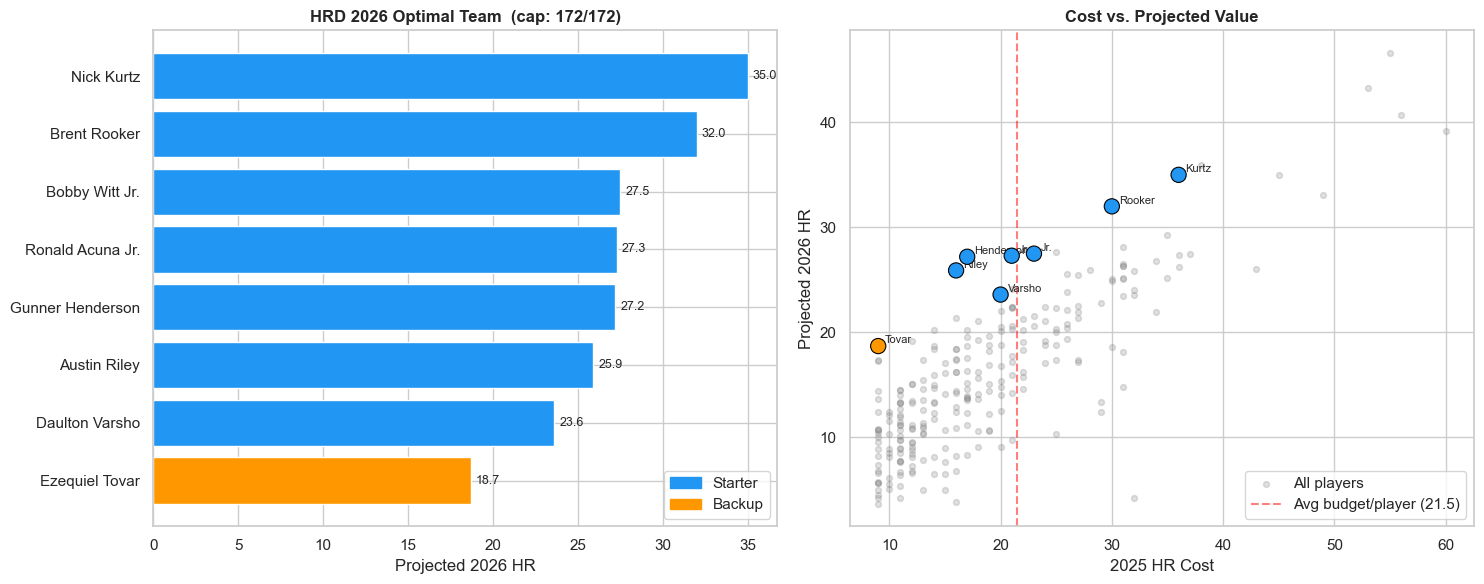

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
palette = ['#2196F3']*7 + ['#FF9800']

# Left: team HR bar chart
ax = axes[0]
t  = team.sort_values('proj_2026')
bars = ax.barh(t['name'], t['proj_2026'], color=palette[::-1], edgecolor='white')
for b, v in zip(bars, t['proj_2026']):
    ax.text(b.get_width()+0.3, b.get_y()+b.get_height()/2, f'{v:.1f}', va='center', fontsize=9)
ax.set_xlabel('Projected 2026 HR')
ax.set_title(f'HRD 2026 Optimal Team  (cap: {cap_used}/172)', fontweight='bold')
ax.legend(handles=[mpatches.Patch(color='#2196F3',label='Starter'),
                   mpatches.Patch(color='#FF9800',label='Backup')])

# Right: cost vs projection scatter
ax2 = axes[1]
ax2.scatter(df['hr_cost'], df['proj_2026'], alpha=0.25, c='gray', s=18, label='All players')
ax2.scatter(team['hr_cost'], team['proj_2026'],
            c=['#2196F3']*7+['#FF9800'], s=120, zorder=5, edgecolors='black', lw=0.8)
for _, r in team.iterrows():
    ax2.annotate(r['name'].split()[-1], (r['hr_cost'], r['proj_2026']),
                 textcoords='offset points', xytext=(5,2), fontsize=8)
ax2.axvline(172/8, color='red', ls='--', alpha=0.5, label='Avg budget/player (21.5)')
ax2.set_xlabel('2025 HR Cost')
ax2.set_ylabel('Projected 2026 HR')
ax2.set_title('Cost vs. Projected Value', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.savefig('hrd_team.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Value Efficiency & Sensitivity

In [15]:
# Top 30 by value ratio (projected HR per cost unit)
print('Top 30 players by projected 2026 HR per cost unit (best bang-for-buck):')
df[['name','team','hr_cost','age','proj_2026','val_ratio']]\
    .sort_values('val_ratio', ascending=False).head(30).reset_index(drop=True)


Top 30 players by projected 2026 HR per cost unit (best bang-for-buck):


,name,team,hr_cost,age,proj_2026,val_ratio
0,Ezequiel Tovar,COL,9,23.0,18.7,2.1
1,Tyler O'Neill,BAL,9,30.0,17.4,1.9
2,Adley Rutschman,BAL,9,27.0,17.3,1.9
3,Austin Riley,ATL,16,28.0,25.9,1.6
4,Gunner Henderson,BAL,17,24.0,27.2,1.6
5,Ryan Jeffers,MIN,9,28.0,14.4,1.6
6,Jorge Soler,LAA,12,33.0,19.2,1.6
7,Masyn Winn,STL,9,23.0,13.7,1.5
8,Nolan Gorman,STL,14,25.0,20.2,1.4
9,Alek Thomas,ARI,9,25.0,12.4,1.4


In [16]:
# Sensitivity: alt-optimal team if we must exclude the #1 projected player
top_uid  = team.iloc[0]['uid']
df_excl  = df[df['uid'] != top_uid].reset_index(drop=True)
n2, c2   = len(df_excl), -df_excl['proj_2026'].values.astype(float)
A2       = np.vstack([df_excl['hr_cost'].values.astype(float), np.ones(n2)])
r2       = milp(c2, constraints=LinearConstraint(A2,[-np.inf,8],[172,8]),
                integrality=np.ones(n2), bounds=Bounds(0,1))

if r2.status == 0:
    alt = df_excl.iloc[np.where(r2.x>0.5)[0]].sort_values('proj_2026',ascending=False)
    alt = alt.reset_index(drop=True)
    alt['role'] = ['STARTER']*7+['BACKUP']
    print(f'Alt team (excl. {top_uid})')
    print(f'  Proj: {alt["proj_2026"].sum():.1f} HR  |  Cost: {int(alt["hr_cost"].sum())}/172')
    print(alt[['name','team','hr_cost','proj_2026','role']].to_string())


Alt team (excl. Nick Kurtz (OAK))
  Proj: 216.1 HR  |  Cost: 172/172
                 name team  hr_cost  proj_2026     role
0         Pete Alonso  BAL       38       35.9  STARTER
1        Brent Rooker  OAK       30       32.0  STARTER
2  Fernando Tatis Jr.   SD       25       27.7  STARTER
3    Ronald Acuna Jr.  ATL       21       27.3  STARTER
4    Gunner Henderson  BAL       17       27.2  STARTER
5        Austin Riley  ATL       16       25.9  STARTER
6     Jackson Merrill   SD       16       21.4  STARTER
7      Ezequiel Tovar  COL        9       18.7   BACKUP
